## Preparation

### Libraries import & metadata storage definitions

In [1]:
import os
import numpy as np
import torch
from time import time

from torch.optim import AdamW, lr_scheduler
from torch.nn import CrossEntropyLoss
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import root_mean_squared_error

from matplotlib import pyplot as plt, colors, cm

In [2]:
checkpoint_dir = "checkpoints_imagenet"
graph_dir = "graphs_imagenet"
os.makedirs(checkpoint_dir, exist_ok=True)
os.makedirs(graph_dir, exist_ok=True)

### Common key functions: plots & training

In [3]:
def plot_metric(trains: list, 
                tests: list, 
                epochs: int, 
                model_name: str = "model",
                dataset_name: str = "dataset",
                metric_name: str = "metric",
                graph_dir: str = "graphs"):
    
    fig, ax = plt.subplots(figsize=(20, 6))
    ax.plot(
        [i+1 for i in range(epochs)],
        trains, 
        "b.-", alpha=0.6, lw=0.3, ms=0.8,
        label="train " + metric_name
    )
    ax.plot(
        [i+1 for i in range(epochs)],
        tests, 
        "r.-", alpha=0.8, lw=0.3,
        label="test " + metric_name
    )
    ax.set(
        title=f"{model_name} {metric_name} on {dataset_name} for {epochs} epochs",
        xlabel="epochs", xlim=(-1, epochs+1), xticks=[i for i in range(0, epochs+1, 5)],
        ylabel=metric_name
    )
    ax.grid(True, alpha=0.3, zorder=0)
    ax.legend()

    plt.savefig(os.path.join(graph_dir, f"regnet_{metric_name}_{epochs}epochs.png"))
    

def centralize_colormap(values, 
                        center: float = 0):
    values_min = values.min()
    values_max = values.max()
    border = max(abs(values_min), abs(values_max))
    
    return colors.TwoSlopeNorm(
        vmin=-border,
        vcenter=center, 
        vmax=border
    )


def plot_heatmap(values,
                 figsize = None,
                 cmap_name: str = "seismic",
                 title: str = "Weights heatmap"):    
    plt.figure(figsize=figsize or (25, 3))
    plt.imshow(
        values, 
        origin="lower",
        cmap=cmap_name, 
        norm=centralize_colormap(values),
        extent=(0, len(values[0]) + 1, 0, len(values) + 1)
    )  
    plt.title(title)  
    plt.colorbar()  
    plt.show() 


def plot_colored_barplot(values,
                         values_color,
                         cmap_name: str = "seismic",
                         edge_color: str = "black",
                         title: str = "Values barplot",
                         x_label: str = "",
                         y_label: str = ""):
    fig, ax = plt.subplots(figsize=(25, 5))
    
    values_cmap = plt.get_cmap(cmap_name)
    norm = centralize_colormap(values_color)
    ax.bar(
        [i for i in range(len(values))],
        values, 
        color=values_cmap(norm(values_color)),
        edgecolor=edge_color
    )
    
    scalar_map = cm.ScalarMappable(
        cmap=values_cmap, 
        norm=norm
    )
    scalar_map.set_array([])
    colorbar = plt.colorbar(scalar_map, ax=ax)
    colorbar.set_label("Percentage of variance explained")
    
    ax.set(
        title=title,
        xlabel=x_label,
        ylabel=y_label
    )
    plt.grid(True, alpha=0.3, zorder=0)
    plt.show() 

In [4]:
def validate_epoch(model: torch.nn.Module,
                   test_loader: DataLoader,
                   criterion,
                   device: torch.device = torch.device("cpu")):
    model.eval()

    test_loss = 0.0
    correct = 0
    total = 0
        
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, targets)
                
            test_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
        
    test_acc = 100. * correct / total

    return test_loss, test_acc

## Dataset download & instantiation

### ImageNet-1K

В работе рассматривается задача классификации изображений, для которой используются модель [семейства RegNet](https://docs.pytorch.org/vision/main/models/regnet.html) версии RegNet_X_3_2_GF и датасет [ImageNet-1K (ILSVRC2017)](https://www.kaggle.com/competitions/imagenet-object-localization-challenge/overview). 

Датасет ImageNet содержит высокого (различного) разрешения, каждое из которых аннотировано с использованием синсетов WordNet и соотносится с 1 или более из 1000 классов; классы не сбалансированы. Подсеты имеют следующую мощность:
- train - 1,3 млн изображений,
- val - 50 тыс изображений,
- test - 100 тыс изображений.

Модель для ускорения обучения инициализируется весами, предобученными на датасете ImageNet со следующими метриками точности:
- acc1: 78.364,
- acc5: 93.992

без дообучения.

In [ ]:
def make_val_loader_imagenet(val_dir: str, 
                             batch_size: int = 256, 
                             num_workers: int = 4,
                             picture_size: int = 224):
    transforms_val = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(picture_size),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std =[0.229, 0.224, 0.225]
        ),
    ])

    imagenet_val = datasets.ImageNet(
        root=val_dir, 
        split="val", 
        transform=transforms_val
    )

    return DataLoader(
        imagenet_val, 
        batch_size=batch_size, 
        shuffle=True,
        num_workers=num_workers, 
        pin_memory=True
    )

In [ ]:
dataset_dir_imagenet = "/media/user/Hitachi/ILSVRC/Data/CLS-LOC"
dataset_name = "ImageNet"
picture_size = 224

n_classes = 1000
batch_size = 32
num_workers = 4

In [ ]:
print(f"[ ] Creating dataset {dataset_name}...")
val_loader = make_val_loader_imagenet(dataset_dir_imagenet, batch_size, num_workers)
classes_names = val_loader.dataset.classes  # type: ignore
print(f"[V] Dataset {dataset_name} created")

[ ] Creating dataset ImageNet...
[V] Dataset ImageNet created


## Model preparation

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", torch.cuda.get_device_name() if device.type == "cuda" else device.type)

Device: NVIDIA GeForce GTX 1650


### RegNetX_3_2 download & instantiation

In [9]:
print("[ ] Instantiating model...")
regnetx_3_2 = models.regnet_x_3_2gf(weights=models.RegNet_X_3_2GF_Weights.DEFAULT, progress=True)
# regnetx_16 = models.regnet_x_32gf(weights=models.RegNet_X_32GF_Weights.DEFAULT, progress=True)
regnetx_3_2.to(device)
regnetx_3_2_name = "RegNetX_3_2"
print(f"[V] {regnetx_3_2_name} with default weights instantiated")

[ ] Instantiating model...
[V] RegNetX_3_2 instantiated


In [10]:
max_lr = 0.01
weight_decay = 0.001

criterion = CrossEntropyLoss()
optimizer = AdamW(regnetx_3_2.parameters(), lr=max_lr, weight_decay=weight_decay)
scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=200)

## Main pipeline

### Pipeline: validation, binarization, weights fuse

In [19]:
seed = 42
torch.manual_seed(seed)

@torch.inference_mode()
def validate_top1_top5_time(model, 
                            loader: DataLoader, 
                            device: torch.device):
    model.eval()
    top1_correct = 0
    top5_correct = 0
    total = 0
    
    start_time = time()

    for images, targets in loader:
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        logits = model(images)
        _, preds = logits.topk(5, dim=1, largest=True, sorted=True)

        correct = preds.eq(targets.view(-1, 1))
        top1_correct += correct[:, :1].sum().item()
        top5_correct += correct.sum().item()
        total += targets.size(0)
        
    val_time = time() - start_time

    return (top1_correct / total * 100,
            top5_correct / total * 100,
            val_time)
    
def pretty_print_top1_top5_time(model, 
                                loader: DataLoader, 
                                device: torch.device,
                                top1_orig = None,
                                top5_orig = None):    
    top1_new, top5_new, val_time = validate_top1_top5_time(model, loader, device)
    
    if top1_orig is not None:
        drop1 = top1_orig - top1_new
        drop1_report = f", drop: {drop1:.4f}"
    else:
        drop1, drop1_report = None, ""
    if top5_orig is not None:
        drop5 = top5_orig - top5_new
        drop5_report = f", drop: {drop5:.4f}"
    else:
        drop5, drop5_report = None, ""
        
    print(f"    Top-1 Accuracy:  {top1_new:.4f}{drop1_report}")
    print(f"    Top-5 Accuracy:  {top5_new:.4f}{drop5_report}")
    print(f"    Validation time: {val_time:.4f} s")
    return top1_new, top5_new, val_time, drop1, drop5


bin_values = []
def binarize_hook(module, input):
    x, = input
    x_bin = 2 ** ((x+1).log2().mul(2).round().mul(1/2)) - 1
    
    global bin_values
    bin_values = x_bin.unique()
    
    return (x_bin,)


def fuse_avgpool_linear(model, 
                        input_size: int):
    device = next(model.parameters()).device
    
    weights = model.fc.weight.data  # [100, 1008] for RegNetX_3_2 on CIFAR-100
    bias = model.fc.bias.data if (model.fc.bias is not None) else torch.zeros(weights.shape[0])
    
    with torch.no_grad():
        random_input = torch.randn(1, 3, input_size, input_size).to(device)
        features = model.stem(random_input)
        features = model.trunk_output(features)
        features = model.avgpool(features)  # shape = [batch, channels, H, W] = [1, 1008, 1, 1] for RegNetX_3_2 on CIFAR-100
        H, W = features.shape[-2:]
    
    divisor = H * W
    weights_fused = weights.repeat(1, divisor) / divisor
    
    return weights_fused.to(device), bias.to(device)


def replace_linear(model,
                   new_weights,
                   new_bias = None):
    device = next(model.parameters()).device
    dtype = model.fc.weight.dtype 
    model.fc.weight.data = torch.from_numpy(new_weights).to(device, dtype=dtype)
    if new_bias is not None:
        model.fc.bias.data = torch.from_numpy(new_bias).to(device, dtype=dtype)

    
def mostleast_signific_classes(weights: torch.Tensor, 
                               feature_idx: int, 
                               dataloader: DataLoader, 
                               top_k: int = 5):
    class_weights = np.argsort(abs(weights[:, feature_idx]))
    class_names = dataloader.dataset.classes # type: ignore
    
    return {
        "top_classes_ids":        class_weights[-top_k:],
        "top_classes_names":      [class_names[class_id] for class_id in class_weights[-top_k:]],
        "top_classes_weights":    weights[class_weights[-top_k:]],
        "bottom_classes_ids":     class_weights[:top_k],
        "bottom_classes_names":   [class_names[class_id] for class_id in class_weights[:top_k]],
        "bottom_classes_weights": weights[class_weights[:top_k]]
    }

In [12]:
print("\nValidating model before binarizing:")
top1_orig, top5_orig, val_time, _, _ = pretty_print_top1_top5_time(
    regnetx_3_2, val_loader, device
)


[ ] Validating model before binarizing:
    Top-1 Accuracy:  80.9900
    Top-5 Accuracy:  95.4040
    Validation time: 831.6290938854218


In [13]:
print("\n2. Binarizing input of avgpool layer...\n")
regnetx_3_2.avgpool.register_forward_pre_hook(binarize_hook)

print("\n[ ] Validating model after binarizing:")
top1_bin, top5_bin, val_time, _, _ = pretty_print_top1_top5_time(
    regnetx_3_2, val_loader, device, 
    top1_orig=top1_orig, 
    top5_orig=top5_orig
)


2. Binarizing input of avgpool layer...


[ ] Validating model after binarizing:
    Top-1 Accuracy:  77.0520, drop: 3.9380
    Top-5 Accuracy:  94.3120, drop: 1.0920
    Validation time: 513.6715047359467


In [14]:
print("Binary values of last layer input:")
bin_values

Binary values of last layer input:


tensor([ 0.0000, 23.6754], device='cuda:0')

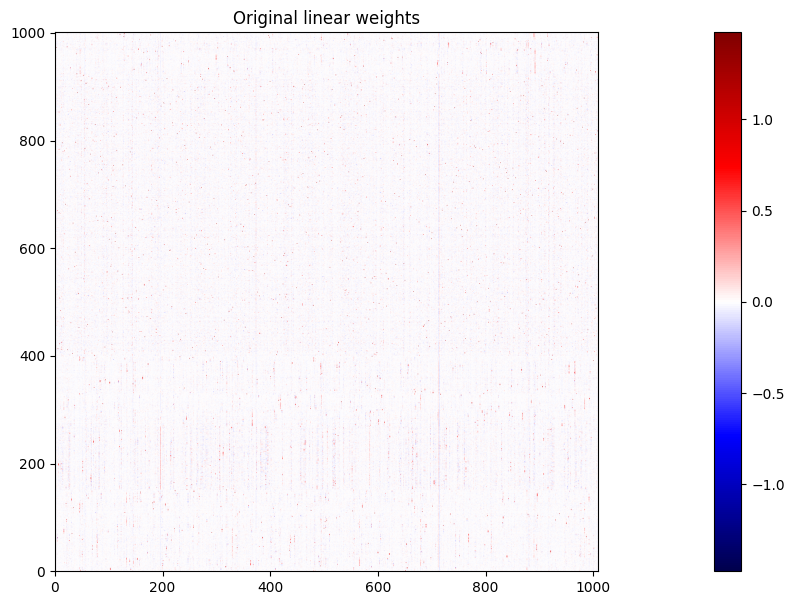

In [18]:
plot_heatmap(regnetx_3_2.fc.weight.data.cpu(), figsize=(30, 7), title="Original linear weights")

In [16]:
print("\n3. Avgpool and linear layers fusing...\n")
weights_fused, bias_fused = fuse_avgpool_linear(regnetx_3_2, picture_size)
print("    Fused weight matrix shape:", weights_fused.shape)  # [100, 1008*H*W]


3. Avgpool and linear layers fusing...



NameError: name 'picture_size' is not defined

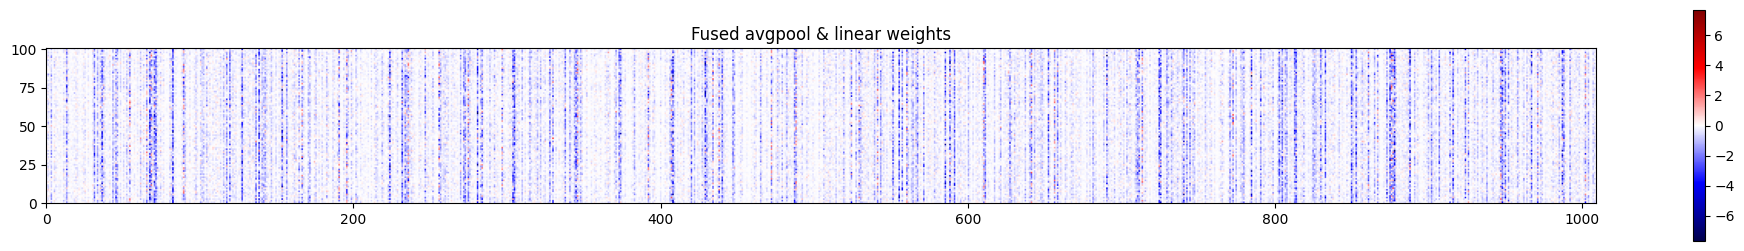

In [ ]:
plot_heatmap(weights_fused.cpu(), title="Fused avgpool & linear weights")

### Significant features extraction

In [ ]:
torch.manual_seed(seed)

n_svd_components = 50

print("\n4. SVD...\n")
svd = TruncatedSVD(n_components=n_svd_components, random_state=seed)
weights_reduced = svd.fit_transform(weights_fused.cpu())
print("    Explained variance ratio:", svd.explained_variance_ratio_.sum())


4. SVD...

    Explained variance ratio: 0.79665077


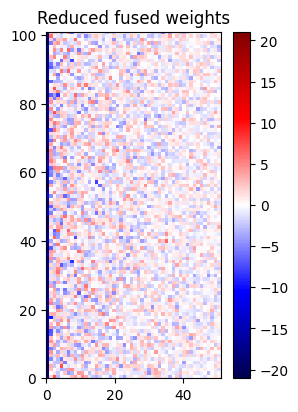

In [ ]:
plot_heatmap(weights_reduced, figsize=(3, 4.5), title="Reduced fused weights")

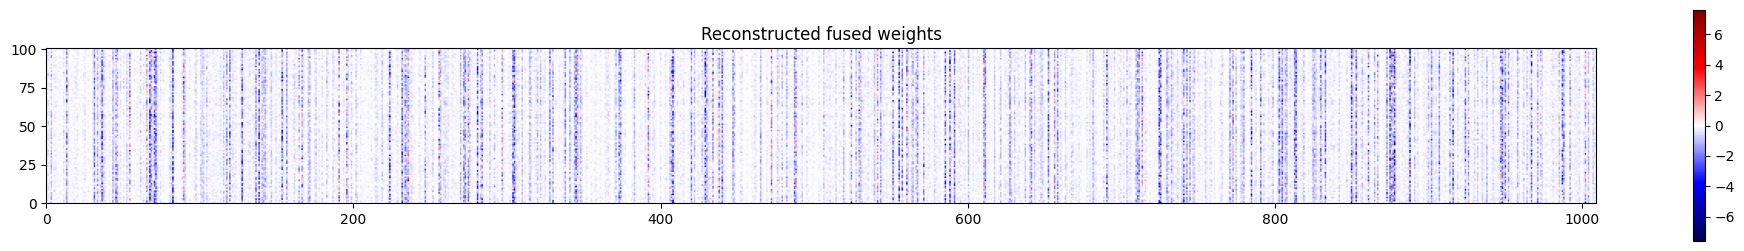

Reconstruction RMSE:      0.191770


In [ ]:
svd_right_sing_vecs = svd.components_  # [n_svd_components, 1008*H*W]
weights_reconstructed = svd.inverse_transform(weights_reduced)

plot_heatmap(weights_reconstructed, title="Reconstructed fused weights")
print(f"Reconstruction RMSE:\
      {root_mean_squared_error(weights_fused.cpu().numpy(), weights_reconstructed):.6f}")

### SVD details analysis


5. Extracting significant features...



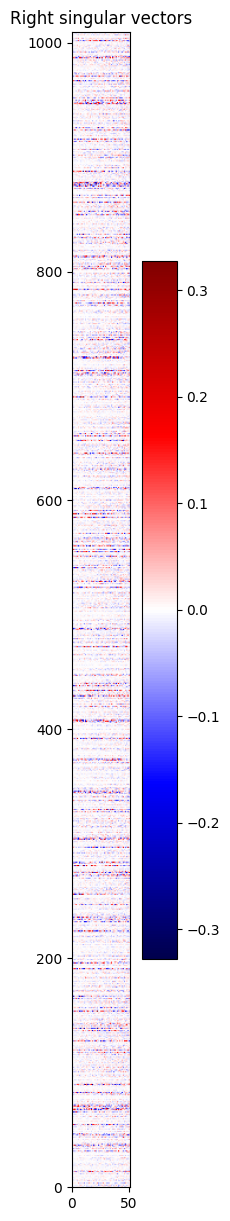

In [ ]:
print("\n5. Extracting significant features...\n")

plot_heatmap(
    np.transpose(svd_right_sing_vecs), 
    figsize=(3, 15),
    title="Right singular vectors"
)

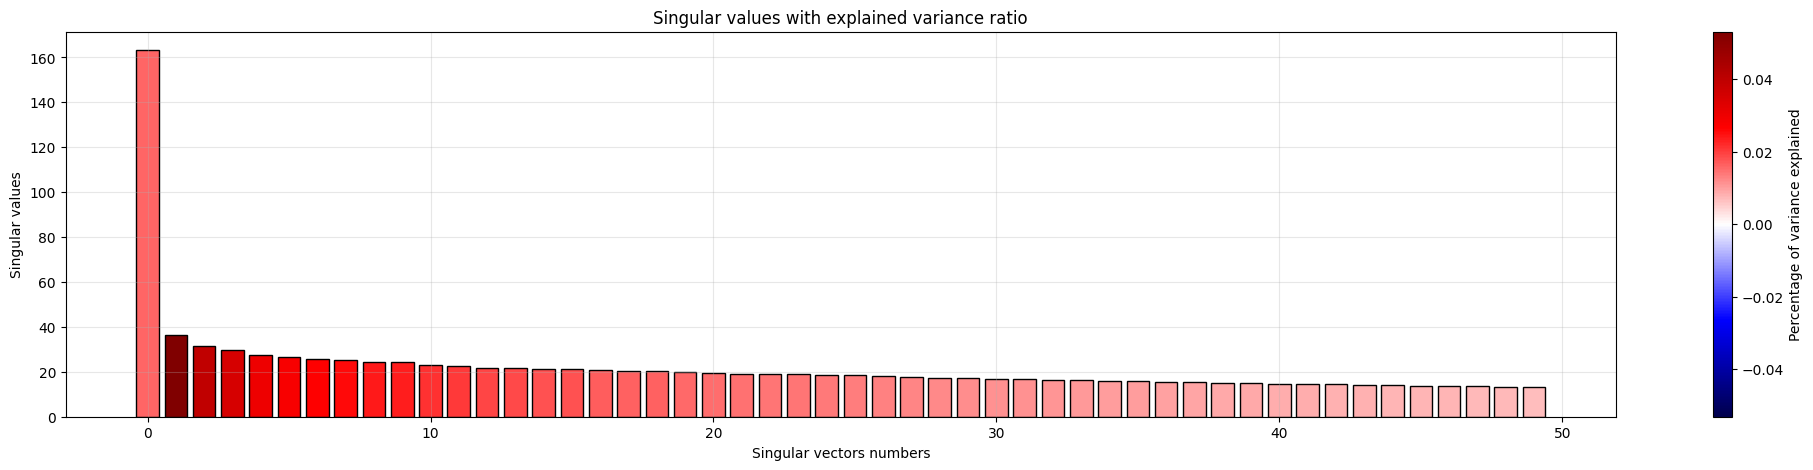

In [ ]:
svd_sing_values = svd.singular_values_
svd_expl_var_ratio = svd.explained_variance_ratio_

plot_colored_barplot(
    values=svd_sing_values,
    values_color=svd_expl_var_ratio,
    title="Singular values with explained variance ratio",
    x_label="Singular vectors numbers",
    y_label="Singular values"
)

In [ ]:
print("Top-5 singular values:                ", svd_sing_values[:5])
print("Top-5 (according) explained variences:", svd_expl_var_ratio[:5])

Top-5 singular values:                 [163.30693   36.425407  31.409609  29.662148  27.492422]
Top-5 (according) explained variences: [0.01590414 0.05304305 0.03938713 0.03516696 0.03021146]


### Significant features count as: singular vectors, reduced features, reconstructed features

In [ ]:
def calc_ljust_spaces(signific_thresholds: list):
    n = 3
    
    thresholds_str = []
    for thr in signific_thresholds:
        thr_str = f"{thr:.{n}f}"
        thresholds_str.append(
            thr_str.rstrip('0').rstrip('.') if ('.' in thr_str) else thr_str
        )
    return thresholds_str, max(len(thr_str) for thr_str in thresholds_str) 


def signific_features_count(weights,
                            signific_thresholds: list,
                            weights_name: str = ""):
    thresholds_str, max_threshold_len = calc_ljust_spaces(signific_thresholds)

    signific_features_ns = [ np.sum(np.abs(weights) >= threshold) 
                             for threshold in signific_thresholds ]

    print(f"    Percent of significant {weights_name} features:")
    for i in range(len(signific_thresholds)):
        print(
            f"        >= {thresholds_str[i].ljust(max_threshold_len)}: ", 
            f"{signific_features_ns[i] / weights.size:.3%}"        
        )
    print("    of all features after SVD")

In [ ]:
print("\n6.1 Counting significant singular features...\n")

signific_sing_thresholds = [0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.4]
signific_features_count(svd_right_sing_vecs, signific_sing_thresholds, "singular")


6.1 Counting significant singular features...

    Percent of significant singular features:
        >= 0.01:  45.155%
        >= 0.05:  7.774%
        >= 0.1 :  2.304%
        >= 0.15:  0.722%
        >= 0.2 :  0.173%
        >= 0.25:  0.052%
        >= 0.4 :  0.000%
    of all features after SVD


In [ ]:
print("\n6.2 Counting significant reduced features...\n")

signific_red_thresholds = [0.5, 1, 2, 3, 5, 10, 15, 20, 25]
signific_features_count(weights_reduced, signific_red_thresholds, "reduced")


6.2 Counting significant reduced features...

    Percent of significant reduced features:
        >= 0.5:  79.720%
        >= 1  :  60.260%
        >= 2  :  30.660%
        >= 3  :  14.420%
        >= 5  :  3.720%
        >= 10 :  2.000%
        >= 15 :  1.480%
        >= 20 :  0.040%
        >= 25 :  0.000%
    of all features after SVD


In [ ]:
print("\n6.2 Counting significant reconstructed features...\n")

signific_rec_thresholds = [0.25, 0.5, 1, 2, 3, 5, 10]
signific_features_count(
    weights_reconstructed, 
    signific_rec_thresholds, 
    "(binary in perspective) reconstructed"
)


6.2 Counting significant reconstructed features...

    Percent of significant (binary in perspective) reconstructed features:
        >= 0.25:  36.399%
        >= 0.5 :  19.976%
        >= 1   :  9.642%
        >= 2   :  2.866%
        >= 3   :  0.802%
        >= 5   :  0.058%
        >= 10  :  0.000%
    of all features after SVD


### Significant features binarization

In [ ]:
print("\n7. Binarizing significant features...\n")
print("7.1 Binary weights analysis:\n")

signific_threshold = 2

filtered_weights = np.where(
    abs(weights_reconstructed) >= signific_threshold, 
    weights_reconstructed, 0
)
weights_binary = 2 ** (
    np.round(np.log2(abs(filtered_weights) + 1) * (1/2.25)) * 2.25
) - 1

filtered_weights_stats = {
    "max":  filtered_weights.max(),
    "min":  filtered_weights.min(),
    "mean": filtered_weights.mean(),
    "sdev": np.std(filtered_weights),
    "binary_values": np.unique(weights_binary)
}

print(f"    Significant (for threshold {signific_threshold}) reduced weights statistics:")
print("        max:      ", filtered_weights_stats["max"])
print("        min:      ", filtered_weights_stats["min"])
print("        mean:     ", filtered_weights_stats["mean"])
print("        deviation:", filtered_weights_stats["sdev"])
print("        binary values:", filtered_weights_stats["binary_values"])


7. Binarizing significant features...

7.1 Binary weights analysis:

    Significant (for threshold 2) reduced weights statistics:
        max:       3.002456
        min:       -7.5825534
        mean:      -0.07650459
        deviation: 0.4809851
        binary values: [0.        3.7568283]


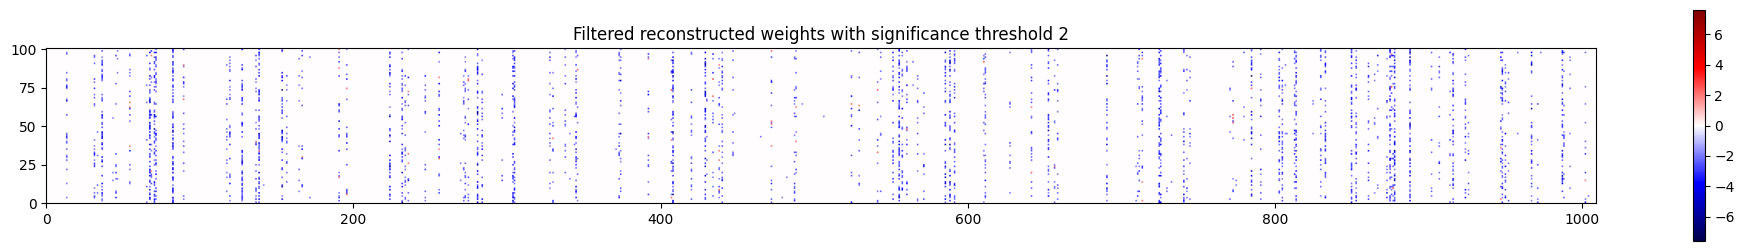

In [ ]:
plot_heatmap(
    filtered_weights, 
    title=f"Filtered reconstructed weights with significance threshold {signific_threshold}"
)

    Binary features values: [0.        3.7568283]
    Binary features shape:  (100, 1008)


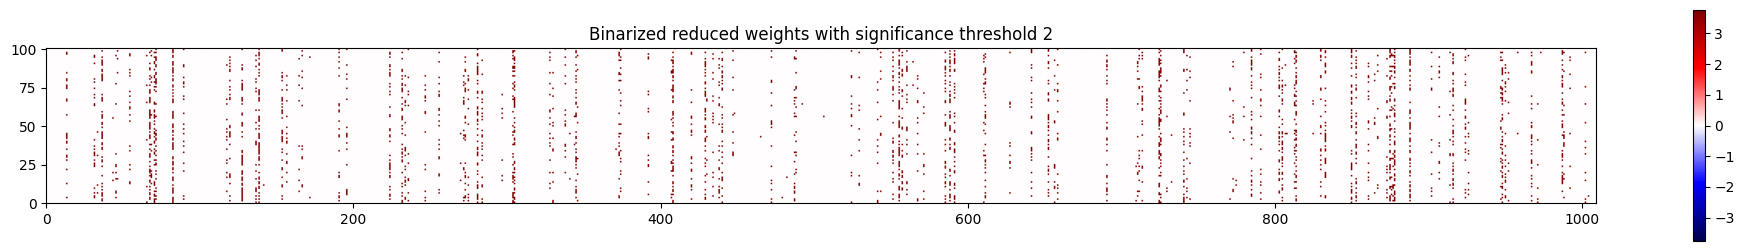

In [ ]:
# weights_binary = (abs(filtered_weights) > 0).astype(int) * filtered_weights_stats["max"] * np.sign(filtered_weights_stats["mean"])
print("    Binary features values:", np.unique(weights_binary))
print("    Binary features shape: ", weights_binary.shape)

plot_heatmap(
    weights_binary, 
    title=f"Binarized reduced weights with significance threshold {signific_threshold}"
)

### Significant features semantic analysis

7.2 Significant classes per feature analysis:



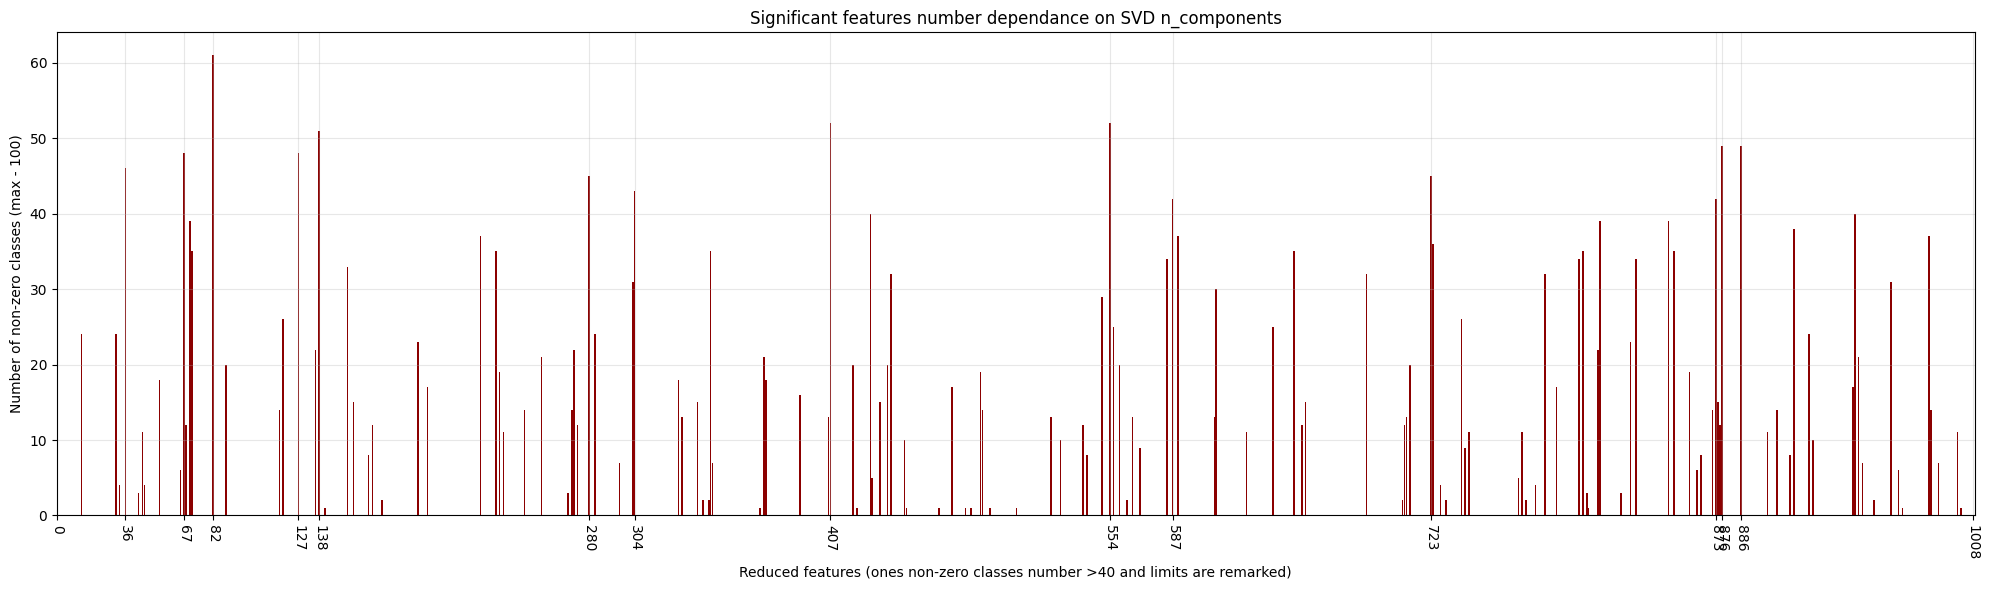

In [ ]:
print("7.2 Significant classes per feature analysis:\n")

n_classes_chosen = [ np.where(weights_binary[:, feature_i])[0].size 
                     for feature_i in range(weights_binary.shape[1]) ]

n_classes_tick_limit = 40
n_largest_classes_ids = [ i for i in range(len(n_classes_chosen))
                          if (n_classes_chosen[i] > n_classes_tick_limit) ]

fig, ax = plt.subplots(figsize=(20, 6))
ax.bar(
    [i for i in range(len(n_classes_chosen))], 
    n_classes_chosen,
    color="darkred"
)

ax.set(
    xticks=n_largest_classes_ids + [0, len(n_classes_chosen)],
    xlim=(0, len(n_classes_chosen) + 1),
    xlabel=f"Reduced features (ones non-zero classes number >{n_classes_tick_limit} and limits are remarked)",
    ylabel=f"Number of non-zero classes (max - {n_classes})", 
    title="Significant features number dependance on SVD n_components"
)
ax.set_xticklabels(ax.get_xticks(), rotation=-90)
ax.grid(alpha=0.3, zorder=0)
plt.tight_layout()
plt.show()

In [ ]:
print("    The following features choose the following classes:\n")
for feature_i in range(weights_binary.shape[1]):
    if n_classes_chosen[feature_i]:
        names_chosen = [ classes_names[name_i] for name_i in np.where(weights_binary[:, feature_i])[0]]
        print(feature_i + 1, " - ", len(names_chosen), "classes: ", names_chosen)

    The following features choose the following classes:

14  -  24 classes:  ['bear', 'bridge', 'chimpanzee', 'crocodile', 'dinosaur', 'dolphin', 'fox', 'kangaroo', 'keyboard', 'lawn_mower', 'leopard', 'lion', 'lizard', 'palm_tree', 'rabbit', 'raccoon', 'shark', 'shrew', 'skunk', 'snake', 'spider', 'sweet_pepper', 'whale', 'willow_tree']
32  -  24 classes:  ['bear', 'beaver', 'bee', 'bottle', 'cloud', 'cockroach', 'couch', 'crocodile', 'dolphin', 'elephant', 'flatfish', 'fox', 'hamster', 'lamp', 'poppy', 'porcupine', 'ray', 'rocket', 'shark', 'snail', 'spider', 'tractor', 'turtle', 'wardrobe']
34  -  4 classes:  ['bee', 'boy', 'dolphin', 'lobster']
37  -  46 classes:  ['aquarium_fish', 'baby', 'beaver', 'bed', 'bee', 'bicycle', 'bowl', 'bridge', 'castle', 'cloud', 'crab', 'crocodile', 'dinosaur', 'fox', 'girl', 'house', 'kangaroo', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'motorcycle', 'mouse', 'mushroom', 'orchid', 'otter', 'palm_tree', 'pickup_truck', 'rabbit', 'raccoon

## ADD-ONs

### Binarization function choice

In [ ]:
def binarize_hook_choice(module, input):
    x, = input
    x_pseudobin = 2 ** (x+1).log2().mul(1/scale_k).round().mul(scale_k) - 1 # type: ignore
    # x_pseudobin = 2 ** (x+1).log2().round() - 1                  #-0.1%  for ResNet50 on CIFAR-10
    # x_pseudobin = 2 ** (x+1).log2().mul(2).round().mul(0.5) - 1  #-0.01% for ResNet50 on CIFAR-10

    print("Binarization gives", len(x_pseudobin.unique()), "values")
    print(x_pseudobin.unique(return_counts=True))
    return (x_pseudobin,) 

In [ ]:
print("\n[ ] Loading original fine-tuned model for CIFAR-100 from checkpoint...")
checkpoint = torch.load(checkpoint_path)
regnetx_3_2 = models.regnet_x_3_2gf()
adapt_model_cifar100(regnetx_3_2, n_classes)
regnetx_3_2.load_state_dict(checkpoint["model_state_dict"])
regnetx_3_2.to(device)
print("[V] Fine-tuned model loaded, its accuracy:", checkpoint["acc"], "\n")

print("\nValidating model before binarizing:")
top1_orig, top5_orig, val_time, _, _ = pretty_print_top1_top5_time(
    regnetx_3_2, val_loader, device 
)


[ ] Loading original fine-tuned model for CIFAR-100 from checkpoint...
[V] Fine-tuned model loaded, its accuracy: 57.34 

[ ] Validating model before binarizing:
    Top-1 Accuracy:  57.34
    Top-5 Accuracy:  81.0
    Validation time: 10.012861967086792
[V] Model validated


In [ ]:
top1_bins, top5_bins, drops1, drops5 = {}, {}, {}, {}

for scale in range(1, 21):
    scale_k = scale/4
    print(f"\n\nBinarization with coeff {scale_k}:")
    
    print("\n[ ] Loading original fine-tuned model for CIFAR-100 from checkpoint...")
    checkpoint = torch.load(checkpoint_path)
    regnetx_3_2 = models.regnet_x_3_2gf()
    adapt_model_cifar100(regnetx_3_2, n_classes)
    regnetx_3_2.load_state_dict(checkpoint["model_state_dict"])
    regnetx_3_2.to(device)
    print("[V] Fine-tuned model loaded, its accuracy:", checkpoint["acc"])

    print("\n[ ] Binarizing avgpool input...")
    regnetx_3_2.avgpool.register_forward_pre_hook(binarize_hook_choice)
    print("[V] Avgpool input binarized into values:", bin_values)

    print("\nValidating model after binarizing avgpool input:")
    top1_bin, top5_bin, val_time, drop1, drop5 = pretty_print_top1_top5_time(
        regnetx_3_2, val_loader, device, 
        top1_orig=top1_orig, 
        top5_orig=top5_orig
    )
    
    top1_bins[scale_k] = top1_bin
    drops1[scale_k] = drop1
    top5_bins[scale_k] = top5_bin
    drops5[scale_k] = drop5



Binarization with coeff 0.25:

[ ] Loading original fine-tuned model for CIFAR-100 from checkpoint...
[V] Fine-tuned model loaded, its accuracy: 57.34

[ ] Binarizing features...
[V] Features binarized

[ ] Validating model after binarizing:
Binarizatin gives 21 values
(tensor([ 0.0000,  0.1892,  0.4142,  0.6818,  1.0000,  1.3784,  1.8284,  2.3636,
         3.0000,  3.7568,  4.6569,  5.7272,  7.0000,  8.5137, 10.3137, 12.4543,
        15.0000, 18.0273, 21.6274, 25.9087, 31.0000], device='cuda:0'), tensor([512243,    235,    233,    225,    259,    262,    319,    352,    306,
           293,    292,    273,    241,    193,    142,    112,     61,     33,
            12,      9,      1], device='cuda:0'))
Binarizatin gives 22 values
(tensor([ 0.0000,  0.1892,  0.4142,  0.6818,  1.0000,  1.3784,  1.8284,  2.3636,
         3.0000,  3.7568,  4.6569,  5.7272,  7.0000,  8.5137, 10.3137, 12.4543,
        15.0000, 18.0273, 21.6274, 25.9087, 31.0000, 37.0546], device='cuda:0'), tensor([512204

In [ ]:
for scale in range(32, 49):
    scale_k = scale/8
    if scale_k in drops1.keys():
        continue
    
    print(f"\n\nBinarization with coeff {scale_k}:")
    
    print("\n[ ] Loading original fine-tuned model for CIFAR-100 from checkpoint...")
    checkpoint = torch.load(checkpoint_path)
    regnetx_3_2 = models.regnet_x_3_2gf()
    adapt_model_cifar100(regnetx_3_2, n_classes)
    regnetx_3_2.load_state_dict(checkpoint["model_state_dict"])
    regnetx_3_2.to(device)
    print("[V] Fine-tuned model loaded, its accuracy:", checkpoint["acc"])

    print("\n[ ] Binarizing features...")
    regnetx_3_2.avgpool.register_forward_pre_hook(binarize_hook_choice)
    print("[V] Features binarized")

    print("\nValidating model after binarizing:")
    top1_bin, top5_bin, val_time, drop1, drop5 = pretty_print_top1_top5_time(
        regnetx_3_2, val_loader, device, 
        top1_orig=top1_orig,
        top5_orig=top5_orig
    )
    
    top1_bins[scale_k] = top1_bin
    drops1[scale_k] = drop1
    top5_bins[scale_k] = top5_bin
    drops5[scale_k] = drop5



Binarization with coeff 5.125:

[ ] Loading original fine-tuned model for CIFAR-100 from checkpoint...
[V] Fine-tuned model loaded, its accuracy: 57.34

[ ] Binarizing features...
[V] Features binarized

[ ] Validating model after binarizing:
Binarizatin gives 2 values
(tensor([ 0.0000, 33.8962], device='cuda:0'), tensor([514997,   1099], device='cuda:0'))
Binarizatin gives 2 values
(tensor([ 0.0000, 33.8962], device='cuda:0'), tensor([514990,   1106], device='cuda:0'))
Binarizatin gives 2 values
(tensor([ 0.0000, 33.8962], device='cuda:0'), tensor([515016,   1080], device='cuda:0'))
Binarizatin gives 2 values
(tensor([ 0.0000, 33.8962], device='cuda:0'), tensor([514928,   1168], device='cuda:0'))
Binarizatin gives 2 values
(tensor([ 0.0000, 33.8962], device='cuda:0'), tensor([514984,   1112], device='cuda:0'))
Binarizatin gives 2 values
(tensor([ 0.0000, 33.8962], device='cuda:0'), tensor([514993,   1103], device='cuda:0'))
Binarizatin gives 2 values
(tensor([ 0.0000, 33.8962], devi

In [ ]:
scale_ks = sorted(drops1.keys())
drops1_truebin = { scale_k: drops1[scale_k] for scale_k in scale_ks if (scale_k >= 4) }
drops5_truebin = { scale_k: drops5[scale_k] for scale_k in scale_ks if (scale_k >= 4) }

drop1_min = min(drops1_truebin.values())
drop5_min = min(drops5_truebin.values())
list(filter(lambda k: drops5[k] == drop5_min, drops5_truebin))

print(f"Minimal top-1 accuracy drop {drop1_min:.2f}", 
      " is achieved with scaling coeff ", 
      list(filter(lambda k: drops1[k] == drop1_min, drops1_truebin)))
print(f"Minimal top-5 accuracy drop {drop5_min:.2f} ", 
      " is achieved with scaling coeff ", 
      list(filter(lambda k: drops5[k] == drop5_min, drops5_truebin)))

Minimal top-1 accuracy drop 9.91  is achieved with scaling coeff  [4.625]
Minimal top-5 accuracy drop 8.85   is achieved with scaling coeff  [4.75]


In [ ]:
drops1_truebin

{4.0: 10.970000000000006,
 4.125: 10.500000000000007,
 4.25: 10.600000000000009,
 4.375: 10.260000000000005,
 4.5: 10.060000000000002,
 4.625: 9.910000000000004,
 4.75: 10.050000000000004,
 4.875: 10.260000000000005,
 5.0: 10.500000000000007,
 5.125: 11.07,
 5.25: 11.590000000000003,
 5.375: 12.240000000000002,
 5.5: 12.950000000000003,
 5.625: 13.5,
 5.75: 14.330000000000005,
 5.875: 15.590000000000003,
 6.0: 17.010000000000005}

In [ ]:
def plot_scale_k_metrics(metric_dicts: list[dict],
                         metric_names: list[str],
                         cmap_name: str = "winter"):
    fig, ax = plt.subplots(figsize=(20, 7))
    metric_cmap = plt.get_cmap(cmap_name)
    
    for i, metric_dict in enumerate(metric_dicts):
        scale_ks = sorted(metric_dict.keys())
        metric_values = [metric_dict[scale_k] for scale_k in scale_ks]
        
        ax.plot(
            scale_ks, 
            metric_values, 
            marker='o', 
            color=metric_cmap(i / len(metric_dicts)),
            label=metric_names[i]
        )
        
    ax.set(
        xticks=scale_ks,
        xlabel="Scaling coefficient",
        yticks=[i for i in range(0, 86, 5)],
        ylabel="Accuracy (in %)",
        title="Accuracy dependence on scaling coefficient"
    )
    ax.set_xticklabels(ax.get_xticks(), rotation=-45)
    ax.grid(True, alpha=0.3, zorder=0)
    ax.legend()

    plt.tight_layout()
    plt.show()

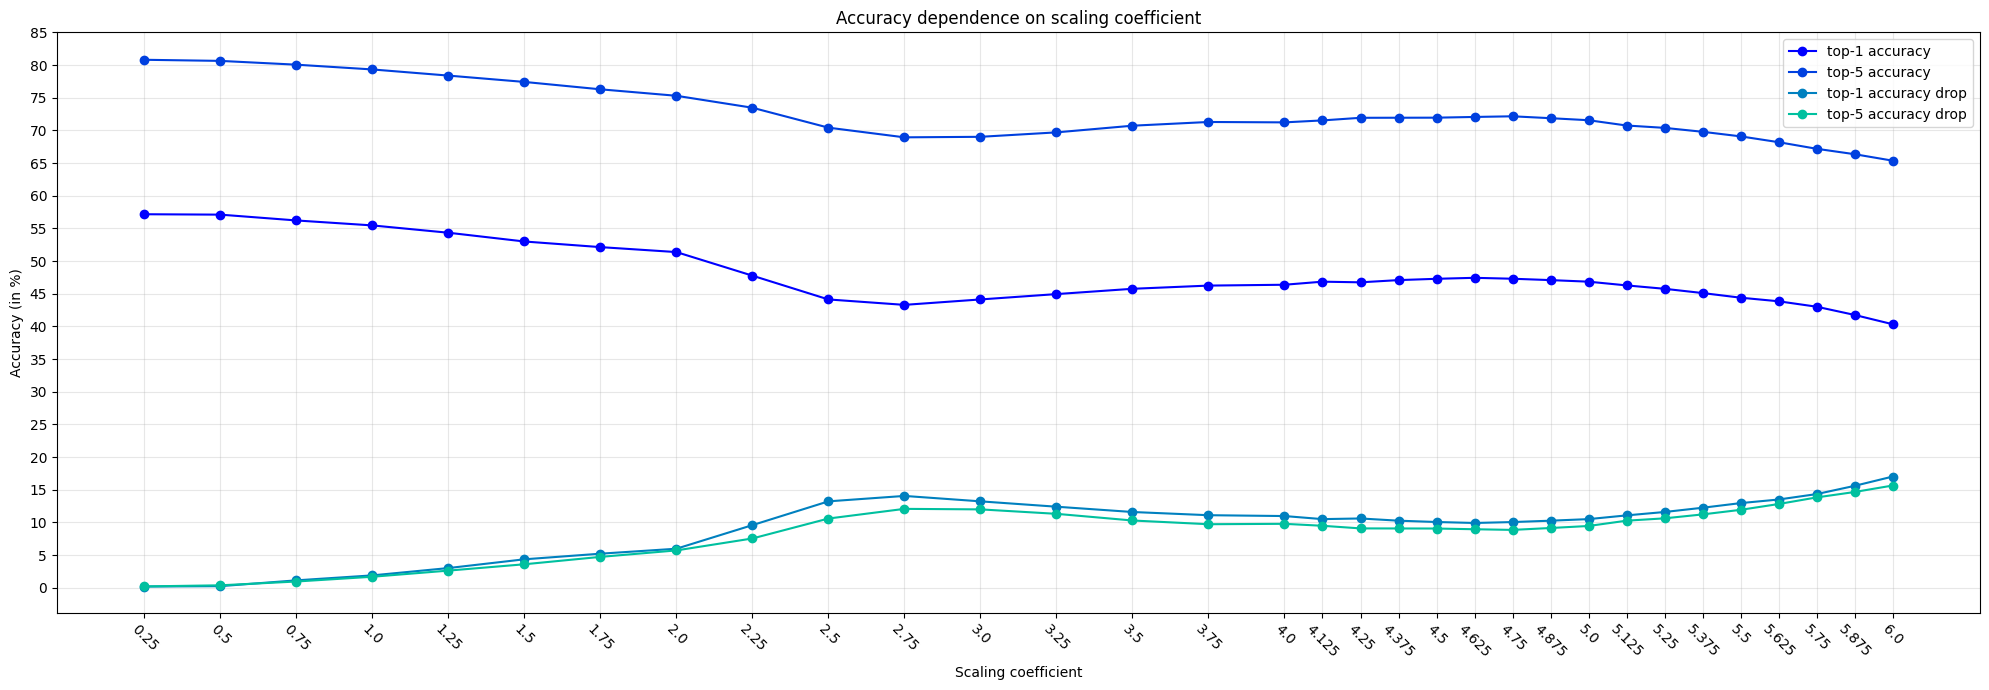

In [ ]:
plot_scale_k_metrics(
    [top1_bins, top5_bins, drops1, drops5],
    ["top-1 accuracy", "top-5 accuracy", "top-1 accuracy drop", "top-5 accuracy drop"]
)